Connecting to HF2LI...
Connected to dev376

Initializing HF2LI...
  Initializing signal inputs...
    Signal inputs initialized.
  Initializing signal outputs...
    Signal outputs initialized.
  Initializing oscillators...
    Oscillators initialized.
  Initializing demodulators...
    Demodulators initialized.
  Initializing PLLs...
    PLLs initialized.
  Initializing PID controllers...
    PID controllers initialized.
  Initializing scope...
    Scope initialized.
  Initializing auxiliary outputs...
    Auxiliary outputs initialized.

Initialization complete.

Configuring output 0...
  Output configured.
Configuring input 0...
  Input configured.
Configuring input 1...
  Input configured.
Configuring demodulator 0...
  Demodulator configured.
Configuring demodulator 1...
  Demodulator configured.

Experiment folder created
Data\2026-08-21_21-47-44

Settings saved.
Data\2026-08-21_21-47-44\settings.txt


Starting frequency sweep
1/200: 700.00 Hz
21/200: 750.25 Hz
41/200: 800.50 Hz
6

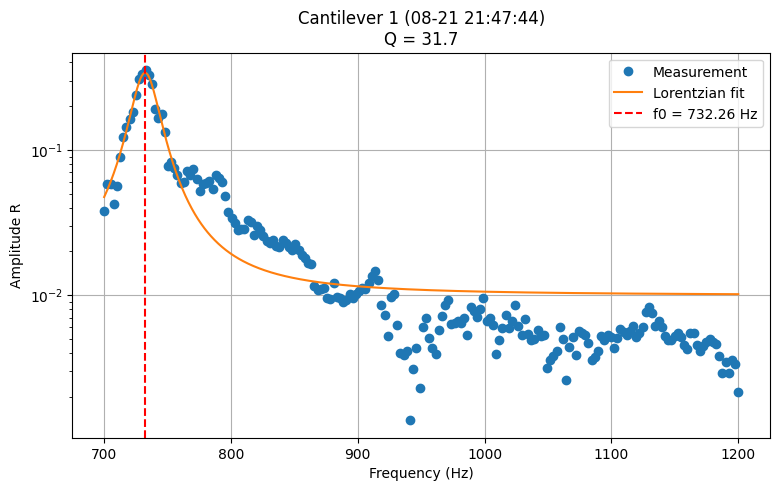

CHECKPOINT 6: PLOT 0 DONE

Starting plot demod 1


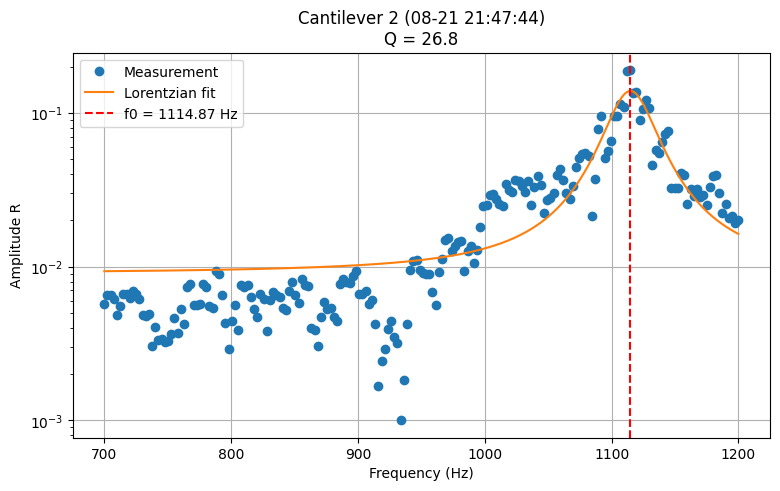

CHECKPOINT 7: PLOT 1 DONE
938.5267907127599 , 0.004084753211313447

Top intersection(s) by amplitude:
Frequency = 938.526791 Hz, Amplitude = 4.084753e-03


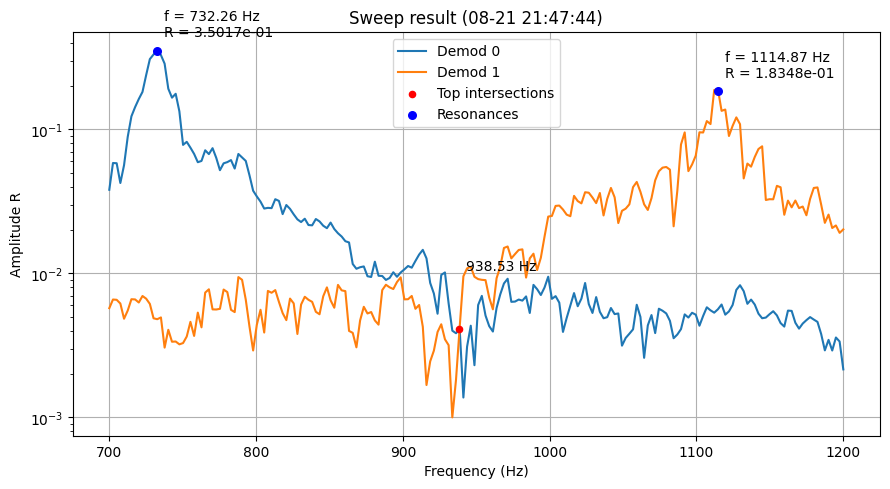

CHECKPOINT 8: SWEEP PLOT DONE.

Saving fit results

Fit saved:
Data\2026-08-21_21-47-44\fit_demod0.json
CHECKPOINT 8: FIT 0 SAVED

Fit saved:
Data\2026-08-21_21-47-44\fit_demod1.json
CHECKPOINT 9: FIT 1 SAVED. --  08-21 21:47:44


In [1]:
import os # enable the file system operation //12AUG YZ
# import json # not necesssary to import json here since the dataio.py imports it //18AUG YZ
from datetime import datetime # added for enabling timestamp in the plot title //07AUG YZ //12AUG YZ

from instrument.hf2li import HF2LI
from instrument import config 

from measurements.sweeper import FrequencySweeper
from measurements.experiment import ExperimentRunner

from utils.dataio import save_sweep_to_folder

from analysis.resonance import fit_resonance


# this cell creates a folder which has the name  of the current date and time. 
# it contains two files: settings.txt and sweep.npz. the settings.txt file contains the settings of the lock-in amplifier, 
# and the sweep.npz file contains the data of the frequency sweep. //06AUG YZ
# Create HF2LI driver, no communication to or control over the instrument yet
lockin = HF2LI(
    device_id=config.DEVICE_ID,
    host=config.SERVER_HOST,
    hf2=config.HF2
)

# connect to instrument.
lockin.connect()

# Initialize the instrument to a known safe state, and every experiment should start from this state.
# - outputs disabled
# - demodulators disabled
# - oscillators reset
# - feedback systems disabled
lockin.initialize()

# Configure experiment

# Signal output
lockin.configure_output(
    channel=config.OUTPUT_CHANNEL,
    amplitude=config.AMPLITUDE,
    offset=config.OFFSET
)

# Signal inputs
lockin.configure_input(
    channel=0,
    input_range=config.INPUT_RANGE_1
)

lockin.configure_input(
    channel=1,
    input_range=config.INPUT_RANGE_2
)

# Demodulators
lockin.configure_demod(
    demod=config.DEMOD_1,
    adc=config.ADC_1,
    oscillator=config.OSCILLATOR_1,
    rate=config.DEMOD_RATE_1
)


lockin.configure_demod(
    demod=config.DEMOD_2,
    adc=config.ADC_2,
    oscillator=config.OSCILLATOR_2,
    rate=config.DEMOD_RATE_2
)

# =========================================================
# Create experiment folder#
# Everything related to this experiment will be saved here:#
# settings.txt
# sweep.npz
# fit results
# interactive measurements#
# =========================================================

# =========================================================
# Experiment metadata#
# General information about this experiment.
# The angle is added for later complex-plane analysis.
# =========================================================

experiment_angle = float(
    input(
        "Experimental angle (deg): "
    )
)
# ask for input the experimental angle in degrees for sweeping  // 13AUG YZ

metadata = {

    "device": config.DEVICE_ID,

    "experiment":
        "Two cantilever resonance measurement",

    "experiment_angle":
        experiment_angle

}


experiment = ExperimentRunner(
    recorder=None,
    settings=config.settings,
    metadata=metadata
)

# =========================================================
# Frequency sweep
# The oscillator frequency is swept.
# Both demodulators are recorded.
# =========================================================

timestamp = datetime.now().strftime("%m-%d %H:%M:%S") # implemenet the timestamp in the plot title //07AUG YZ // move timestamp to the beginning of sweep 12AUG YZ

sweeper = FrequencySweeper(
    lockin
)

data = sweeper.sweep(
    start_frequency=config.F_START,
    stop_frequency=config.F_STOP,
    points=config.POINTS,
    demods=(0,1),
    live_plot=False # change to false to disable live plotting //10AUG YZ
)

lockin.disable_excitation()

print()
print("Sweep finished.")
print(data.keys())
print()

# =========================================================
# Save sweep
# The raw sweep is stored inside the experiment folder.
# =========================================================

sweep_file = save_sweep_to_folder(
    data,
    experiment.run_folder
)

print("Experiment folder:")
print(experiment.run_folder)

print("sweepfile")
print(sweep_file)

## =========================================================
# Load saved sweep data
#
# We analyze the saved raw measurement.
# The instrument data itself is not modified.
# =========================================================

import numpy as np

print()
print("CHECKPOINT 1: Loading sweep")
loaded = np.load(
    sweep_file,
    allow_pickle=True
)

print("Loaded file:")
print(sweep_file)

print()
print("Available channels:")
print(loaded.files)


# =========================================================
# Convert numpy archive into dictionary
# =========================================================

data_loaded = {
    key: loaded[key]
    for key in loaded.files
}

print()
print("CHECKPOINT 2: Sweep converted to dictionary")

# =========================================================
# Extract frequency and amplitudes
#
# Demod 0 -> first cantilever
# Demod 1 -> second cantilever
# =========================================================

from analysis.parser import (
    get_frequency,
    get_channel
)

frequency = get_frequency(data_loaded)

amplitude_0 = get_channel(
    data_loaded,
    demod=0,
    quantity="r"
)

amplitude_1 = get_channel(
    data_loaded,
    demod=1,
    quantity="r"
)

print()
print("CHECKPOINT 3: Channels extracted")
print(
    "Frequency points:",
    len(frequency)
)
print(
    "Demod 0:",
    len(amplitude_0)
)
print(
    "Demod 1:",
    len(amplitude_1)
)

# Resonance fitting

from analysis.resonance import fit_resonance

print()
# cantilever 1/channel 1 resonance fit
print("Starting fit demod 0")
fit_0 = fit_resonance(
    frequency,
    amplitude_0
)# resonance frequency and amplitude
print()
print("Demod 0")
print(fit_0)
print("CHECKPOINT 4: FIT 0 DONE")

# fit_0 = fit_resonance get a output with structure as: //13AUG YZ
    # fit_0["f0"]          # resonance frequency
    # fit_0["gamma"]       # linewidth
    # fit_0["Q"]           # quality factor
    # fit_0["parameters"]  # fitting parameters
    # fit_0["covariance"]  # fitting uncertainty information
# there is no amplitude included in it //13AUG YZ


print()
# cantilever 2/channel 2 resonance fit
print("Starting fit demod 1")
fit_1 = fit_resonance(
    frequency,
    amplitude_1
)# resonance frequency and amplitude
print()
print("Demod 1")
print(fit_1)
print("CHECKPOINT 5: FIT 1 DONE")


# Plot resonance fits

from analysis.plotting import plot_resonance_fit
from analysis.plotting import plot_sweep

print()
print()

print(experiment.run_folder)

print("plot resonance")

plot_resonance_fit( # save the plot of the resonance has been added//15AUG YZ
    frequency,
    amplitude_0,
    fit_0,
    # title="Cantilever 1"
    save_path = os.path.join(
        experiment.run_folder,
        "resonance_cantilever_1.png"
    ),
    title=f"Cantilever 1 ({timestamp})"
)
print("CHECKPOINT 6: PLOT 0 DONE")

print()
print("Starting plot demod 1")
plot_resonance_fit(
    frequency,
    amplitude_1,
    fit_1,
    # title="Cantilever 2"
    save_path = os.path.join(
        experiment.run_folder,
        "resonance_cantilever_2.png"
    ),
    title=f"Cantilever 2 ({timestamp})"

)
print("CHECKPOINT 7: PLOT 1 DONE")

plot_sweep(
    frequency,
    amplitude_0,
    amplitude_1,
    fit_0,
    fit_1,
    timestamp=timestamp,
    save_path=os.path.join(
        experiment.run_folder,
        "sweep.png"
    )
)

# move resonance resulting and plotting here, ends //11AUG YZ

# plot the sweep result, begins //12AUG YZ
# move plotting of sweep to plotting.py begins //15AUG YZ
# move plotting of sweep to plotting.py ends //15AUG YZ
# plot the sweep result, ends //12AUG YZ
print("CHECKPOINT 8: SWEEP PLOT DONE.")
from utils.dataio import save_fit

print()

print("Saving fit results")

save_fit(
    fit_0,
    experiment.run_folder,
    filename="fit_demod0.json"
)

print("CHECKPOINT 8: FIT 0 SAVED")

save_fit(
    fit_1,
    experiment.run_folder,
    filename="fit_demod1.json"
)

print("CHECKPOINT 9: FIT 1 SAVED. -- ", timestamp)


In [2]:
# move to 1st cell to show resonance plotting, begins //11AUG YZ
# move to 1st cell to show resonance plotting, ends//11AUG YZ

# f0 = fit_0["f0"] commented to run a specified test with two cantilevers under 900 Hz //12AUG
# f0 = 915
# set the CH1 resonance frequency as the oscillator frequency for the next stps //07AUG YZ

import os

while True: # initial input for the experiment frequency //15AUG YZ

    f0_input = input(
        "Experiment frequency, q = quit: "
    ).strip()

    if f0_input.lower() == "q":
        print("Experiment finished.")
        raise SystemExit

    try:
        f0 = int(f0_input) # only accept an integer for input//15AUG YZ
        break

    except ValueError:
        print("Invalid input. Please enter an integer or q.")


frequency_file = os.path.join( #
    experiment.run_folder,
    f"{f0}_Hz.txt" # entered frequency will be the filename //15AUG YZ
)

while True:

    distance_input = input(
        "Distance, q = quit: "
    ).strip()

    if distance_input.lower() == "q":
        print("Experiment finished.")
        raise SystemExit

    try:
        distance = float(distance_input)
        break

    except ValueError:
        print("Invalid input. Please enter a number or q.")

with open(frequency_file, "w") as file: # write the distance value into file created //15AUG YZ
    file.write(f"{distance}\n")


# fit result saving is moved to the 1st cell, begins //18AUG YZ
# fit result saving is moved to the 1st cell, ends //18AUG YZ

print()
print("Setting HF2LI frequency") #experiment frequency defined by user input //16AUG YZ


lockin.set_frequency(f0)
lockin.disable_excitation()

print("CHECKPOINT 10: FREQUENCY SET")

# =========================================================
# Prepare interactive measurement
# =========================================================

from measurements.recorder import HF2LIRecorder

print()

print("Creating recorder")

recorder = HF2LIRecorder(
    lockin,
    demods=(0,1)
)

print("CHECKPOINT 11: RECORDER CREATED")

# Attach recorder to existing experiment

experiment.recorder = recorder
print("CHECKPOINT 12: RECORDER ATTACHED")

# =========================================================
# Start interactive experiment
# =========================================================


print()
print("STARTING INTERACTIVE EXPERIMENT")

experiment.run(
    duration=2.0
)


Setting HF2LI frequency
Excitation disabled
CHECKPOINT 10: FREQUENCY SET

Creating recorder
CHECKPOINT 11: RECORDER CREATED
CHECKPOINT 12: RECORDER ATTACHED

STARTING INTERACTIVE EXPERIMENT
Excitation disabled

--------------------------------
Measurement 1

Recording...
Starting measurement
Excitation enabled
Streaming: ['/dev376/demods/0/sample', '/dev376/demods/1/sample']
Demod 0 points: 1795
Demod 1 points: 1785
Synchronizing to 1785 points
Points recorded: 1785
Excitation disabled
Excitation disabled
Recording finished.
DEBUG experiment_angle = 0.0
Saved: Data\2026-08-21_21-47-44\001_angle_0.npy
Excitation disabled

--------------------------------
Measurement 2

Recording...
Starting measurement
Excitation enabled
Streaming: ['/dev376/demods/0/sample', '/dev376/demods/1/sample']
Demod 0 points: 1797
Demod 1 points: 1789
Synchronizing to 1789 points
Points recorded: 1789
Excitation disabled
Excitation disabled
Recording finished.
DEBUG experiment_angle = 45.0
Saved: Data\2026-08-

Reading:
Data\2026-08-21_21-47-44
Loaded: 001_angle_0.npy
{'time': array([        0,    233472,    466944, ..., 416047104, 416280576,
       416514048], shape=(1785,), dtype=uint64), 'x_0': array([0.05143107, 0.05427785, 0.05716589, ..., 0.19500418, 0.19500397,
       0.19500438], shape=(1785,)), 'y_0': array([0.15576198, 0.16110164, 0.16635095, ..., 0.30545597, 0.30546998,
       0.30548322], shape=(1785,)), 'r_0': array([0.16403338, 0.16999948, 0.17589933, ..., 0.36239478, 0.36240648,
       0.36241786], shape=(1785,)), 'phase_0': array([71.72728662, 71.38046518, 71.0349057 , ..., 57.44569378,
       57.44691422, 57.44798577], shape=(1785,)), 'x_1': array([0.00155386, 0.00160258, 0.00164952, ..., 0.00141093, 0.00140768,
       0.00140461], shape=(1785,)), 'y_1': array([0.00298982, 0.00306323, 0.00313429, ..., 0.00491073, 0.00491584,
       0.00491995], shape=(1785,)), 'r_1': array([0.0033695 , 0.00345711, 0.00354185, ..., 0.0051094 , 0.00511342,
       0.00511653], shape=(1785,)), 'p

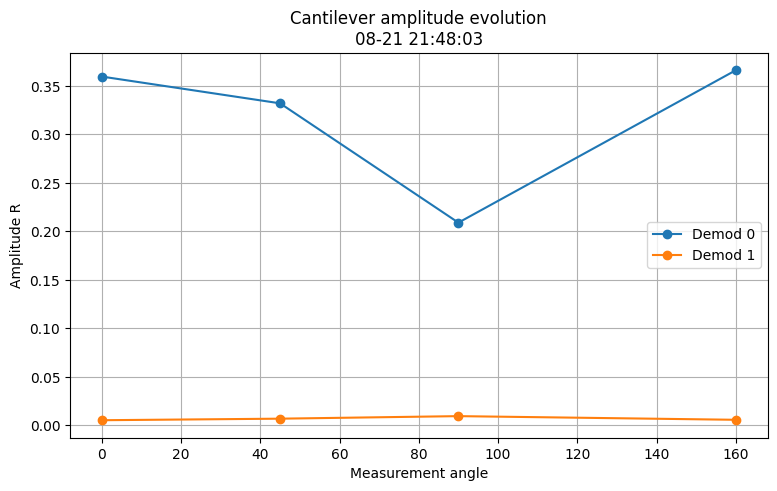

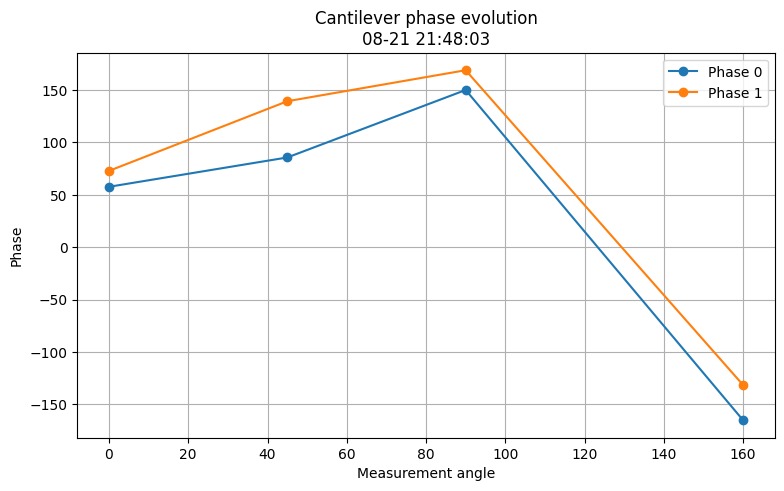

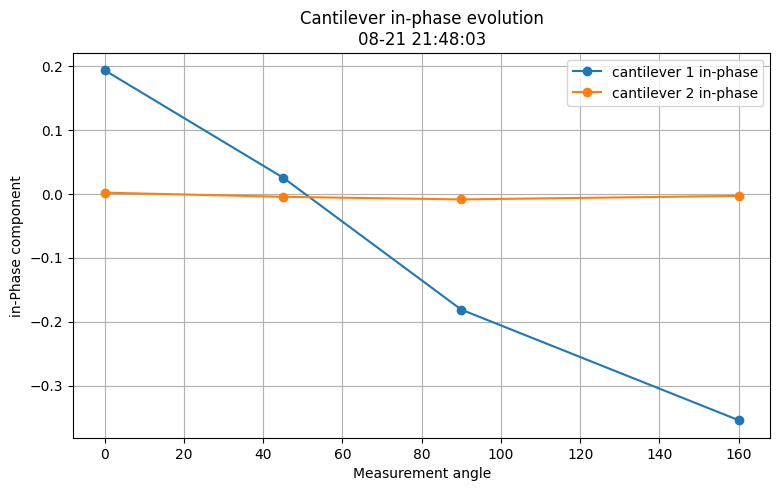

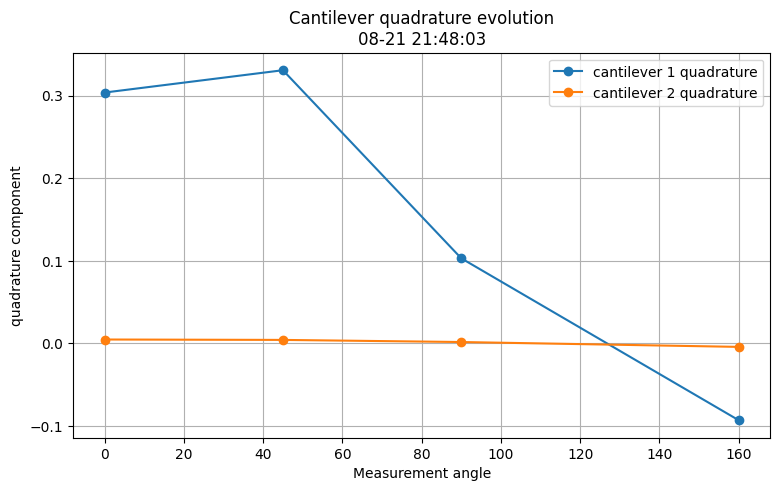

summary and its plottings are done
08-21 21:49:46
71 67 77 89
=-=-=-=-=-=


In [3]:
# new cell for loading calibration files to generate summary //17AUG YZ
import numpy as np
import json
import os

from datetime import datetime
s_timestamp = datetime.now().strftime("%m-%d %H:%M:%S") #timestamp of excution of summary //18AUG YZ

from analysis.measurement_reader import (
    load_measurements,
    summarize_measurements
)
from utils.dataio import save_summary

experiment_folder = r"Data\2026-08-21_21-47-44" # path for calibration, manual input required

print("Reading:")
print(experiment_folder)

measurements = load_measurements( 
    experiment_folder
)

summary = summarize_measurements(
    measurements
)

save_summary(
    summary,
    experiment_folder
)

print(summary)
print(s_timestamp)
####### new cell of summary combined ########

print("Reading:")

print(experiment_folder)

print("fit reading")

fit0_file = os.path.join(
    experiment_folder,
    "fit_demod0.json"
)

fit1_file = os.path.join(
    experiment_folder,
    "fit_demod1.json"
)

with open(fit0_file,"r") as f:

    fit0 = json.load(f)

with open(fit1_file,"r") as f:

    fit1 = json.load(f)

print()
print("Fit demod 0:")
print(fit0)


print()
print("Fit demod 1:")
print(fit1)

# move plot of summary of amplitude and phase here, begins//13AUG YZ
from analysis.plotting import (
    plot_amplitude_summary,
    plot_phase_summary,
    plot_xcomp_summary,
    plot_ycomp_summary    
)

plot_amplitude_summary(
    summary,
    save_path=os.path.join(
        experiment_folder,
        "amplitude_summary.png"
    )
)

plot_phase_summary(
    summary,
    save_path=os.path.join(
        experiment_folder,
        "phase_summary.png"
    )
)

plot_xcomp_summary(
    summary,
    save_path=os.path.join(
        experiment_folder,
        "x_comp.png"
    )
)

plot_ycomp_summary(
    summary,
    save_path=os.path.join(
        experiment_folder,
        "y_comp.png"
    )
)

print("summary and its plottings are done")
print(s_timestamp)
# move plot of summary of amplitude and phase here, ends //13AUG YZ
# save the plot of phase //15AUG YZ
print("71 67 77 89")
print("=-=-=-=-=-=")


Calibration built from CSV
Source: Data\2026-08-21_21-47-44\summary.csv
Number of angles: 4
{'angles': array([  0.,  45.,  90., 160.]), 'Cantilever 1': array([ 0.19281294+0.30360053j,  0.02504338+0.3306137j ,
       -0.18134376+0.10304252j, -0.35419552-0.09283228j]), 'Cantilever 2': array([ 0.00147704+0.004816j  , -0.00502764+0.00432948j,
       -0.00908837+0.00177449j, -0.00362674-0.00410047j]), 'ratio_points': array([68.84329195-18.92203408j, 29.65542599-40.22190323j,
       21.35305173 -7.16868789j, 55.56859568-37.23054818j]), 'diff_points': array([ 0.1913359 +0.29878453j,  0.03007101+0.32628422j,
       -0.17225538+0.10126803j, -0.35056878-0.08873181j]), 'ratio_mean_mag': array([71.34041238, 50.01068462, 22.56264462, 66.79519995]), 'r_0': array([0.35973042, 0.33209259, 0.20894474, 0.36626483]), 'r_1': array([0.00504245, 0.00664043, 0.00926065, 0.0054834 ]), 'phase_0': array([  57.64982025,   85.65953329,  150.05955151, -165.22082616]), 'phase_1': array([  72.8530127 ,  139.3507021

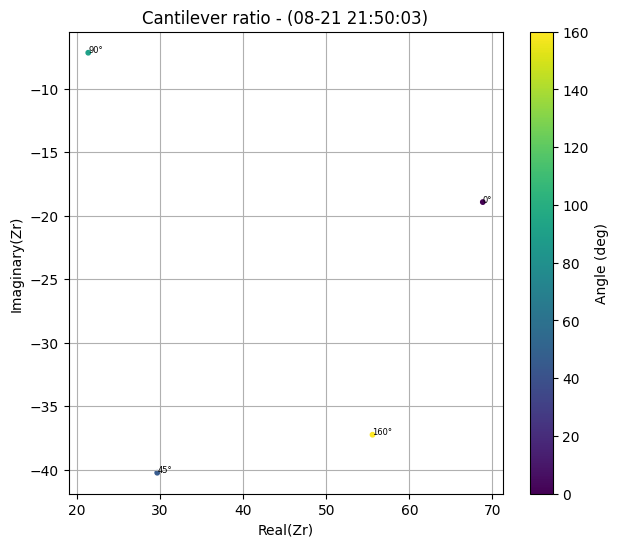

calibration by ratio of mean of responses plotted and saved 08-21 21:50:03


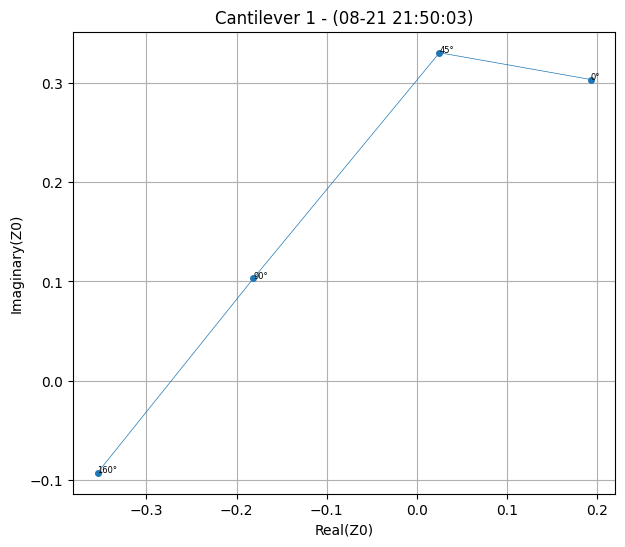

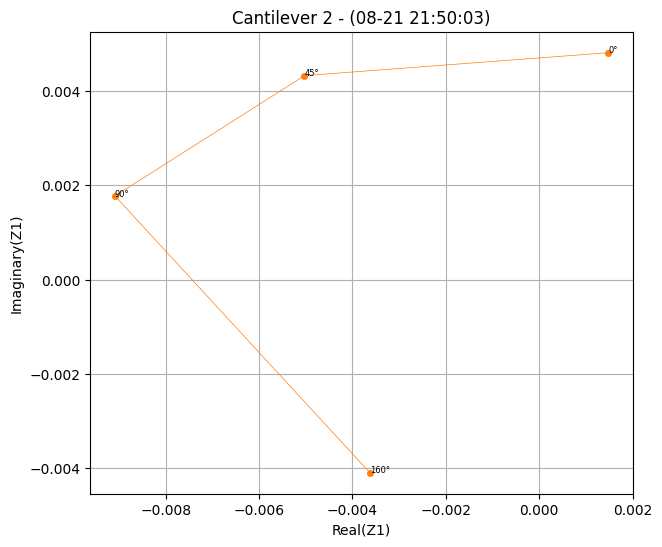

calibration by cantilevers complex responses plotted and saved 08-21 21:50:03


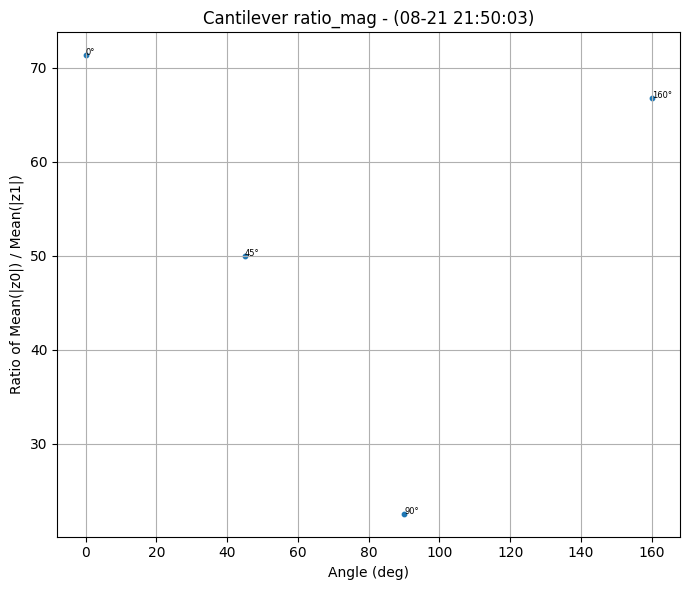

calibration by ration of mean magnitude plotted and saved 08-21 21:50:03


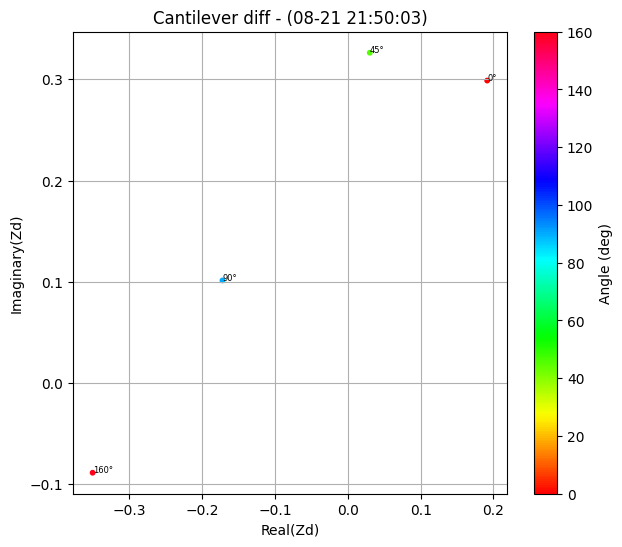

calibration by difference of cantilever plotted and saved 08-21 21:50:03


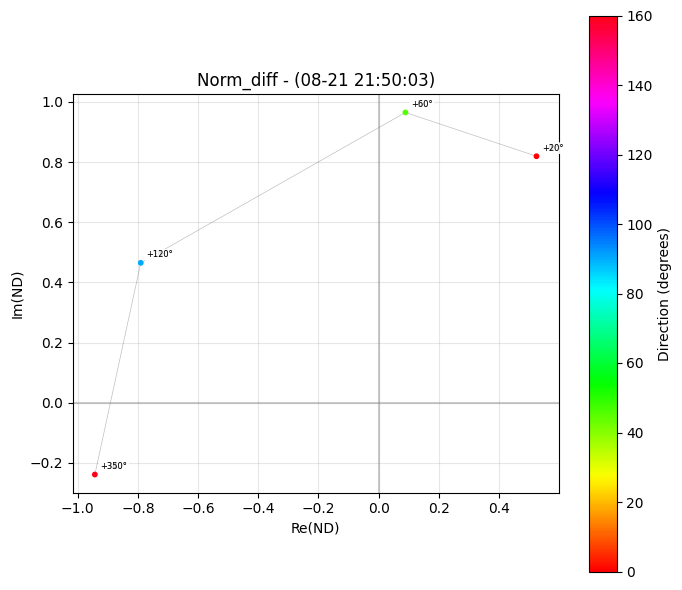

calibration by norm_diff plotted and saved 08-21 21:50:03
calibration and plots are done
08-21 21:50:20


In [5]:
from datetime import datetime
import os

timestamp = datetime.now().strftime("%m-%d %H:%M:%S")
from analysis.calibration import save_calibration
from analysis.calibration import build_calibration_from_csv
from analysis.calibration import load_calibration

from analysis.calibration_plot import plot_calibration
from analysis.calibration_plot import plot_calibration_cantilevers #11AUG YZ
from analysis.calibration_plot import plot_calibration_diff #12AUG YZ
from analysis.calibration_plot import plot_calibration_rmmag
from analysis.calibration_plot import plot_calibration_norm_diff #19AUG YZ



experiment_folder = r"Data\2026-08-21_21-47-44" # input the experiement folder //13AUG YZ

# build the calibration file //13AUG YZ
calibration = build_calibration_from_csv(
   experiment_folder # original = r"Data\2026-08-13_18-14-05", changed to use identified folder
)


save_calibration(
     calibration,
#     #experiment_folder + r"Data\2026-08-13_18-14-05\calibration.npy"
   experiment_folder + r"\calibration_from_summary.npy"
 )
calibration = load_calibration(
    experiment_folder + r"\calibration_from_summary.npy"
)

# calibration = load_calibration(
#      experiment_folder + r"\calibration.npy"
# )

plot_calibration(
    calibration,
    save_path=os.path.join(
            experiment_folder,
            "ratio_mean_cplx.png")
    )#plot cantilever 1 / cantilever 2

plot_calibration_cantilevers(
    calibration,
    save_path_CL1 = os.path.join(
            experiment_folder,
            "mean_CL1.png"),
    save_path_CL2 = os.path.join(
            experiment_folder,
            "mean_CL2.png")
)#plot cantilever characteristics from CH1 CH2 //11AUG YZ

plot_calibration_rmmag(
    calibration,
    save_path=os.path.join(
        experiment_folder,
        "ratio_mean_mag.png") #plot Mean(|z0|) / Mean(|z1|) 
)

plot_calibration_diff(
    calibration,
    save_path=os.path.join(
        experiment_folder,
        "diff_mean.png") 
) #plot cantilever 1 - cantilever 2



plot_calibration_norm_diff(
    calibration,
    save_path=os.path.join(
        experiment_folder,
        "mean_norm_diff.png") #plot normalized difference (mean(z0)-mean(z1))/(abs(mean(z0))+abs(mean(z1))) //19AUG YZ
)

print("calibration and plots are done")
print(timestamp)

In [7]:
experiment.loc_run(
    duration=2.0
)
print(experiment.run_folder)

Excitation disabled


Recording...
Starting measurement
Excitation enabled
Streaming: ['/dev376/demods/0/sample', '/dev376/demods/1/sample']
Demod 0 points: 1801
Demod 1 points: 1793
Synchronizing to 1793 points
Points recorded: 1793
Excitation disabled
Excitation disabled
Recording finished.
DEBUG experiment_angle = 90.0
Saved: Data\2026-08-21_21-47-44\AUE_angle_90.npy
Data\2026-08-21_21-47-44



{'angle': array([110.]), 'Cantilever 1': array([-0.2151747+0.07432621j]), 'Cantilever 2': array([-0.00960563-0.00043249j]), 'ratio_points': array([22.00788739-8.72866546j]), 'diff_points': array([-0.20556907+0.0747587j]), 'ratio_mean_mag': array([23.67575961]), 'r_0': array([0.2276792]), 'r_1': array([0.00961655]), 'phase_0': array([161.00466426]), 'phase_1': array([-168.73823671]), 'norm_diff': array([-0.86640982+0.3150847j]), 'source_files': ['AUE_angle_110.npy'], 'created': '2026-08-21T21:51:45.107363'}

[-0.86640982+0.3150847j]

[{'index': np.int64(2), 'angle': np.float64(90.0), 'calibration_point': np.complex128(-0.7907627041707075+0.46488521061177396j), 'magnitude': np.float64(0.9172916184905011), 'magnitude_diff': np.float64(0.004632646360478665)}, {'index': np.int64(1), 'angle': np.float64(45.0), 'calibration_point': np.complex128(0.08891600660942965+0.9647792891948294j), 'magnitude': np.float64(0.9688679647354682), 'magnitude_diff': np.float64(0.04694369988448843)}, {'index':

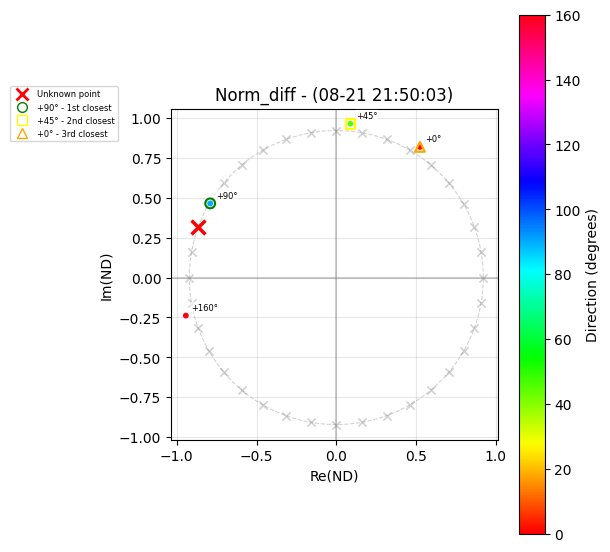

estimation plotted and saved 08-21 21:50:03
71 67 77 89
=-=-=-=-=-=


In [9]:
from measurements.experiment import con_AUE # convert an AUE file to a variant//20AUG YZ
from measurements.experiment import est_LDND # estimation by LDND //21AUG YZ
# LDND = Least difference of normalized difference //21AUG YZ
from analysis.calibration_plot import plot_loc_est # plot estimation //21AUG YZ

point_loc = con_AUE(
    experiment.run_folder + r"\AUE_angle_110.npy"
)
# convert the measurement file of the interested point to an dictionary variant //21AUG YZ
print()
print(point_loc)

norm_diff_point_loc = point_loc["norm_diff"] # take out the value of normalized difference from the above variant //20AGU YZ

print()
print(norm_diff_point_loc)


AUE_LDND = est_LDND ( 
    norm_diff_point_loc, 
    experiment.run_folder + r"\calibration_from_summary.npy"
)
print()
print(AUE_LDND)

plot_loc_est(
    norm_diff_point_loc,
    AUE_LDND,
    experiment.run_folder + r"\calibration_from_summary.npy",
    experiment.run_folder + r"\estimation_" + os.path.splitext(os.path.basename(point_loc["source_files"][0]))[0] + ".png"
)

print("71 67 77 89")
print("=-=-=-=-=-=")


In [2]:
from project_summary import summarize_project

summarize_project()



TWO CANTILEVERS LOCK-IN FRAMEWORK

################################################################################
INSTRUMENT
################################################################################

instrument

instrument.hf2li

CLASSES


CLASS: HF2LI
    Driver class for the Zurich Instruments HF2LI.
    __init__(self, device_id, host='localhost', hf2=True)
    _initialize_aux_outputs(self)
    _initialize_demodulators(self)
    _initialize_inputs(self)
    _initialize_oscillators(self)
    _initialize_outputs(self)
    _initialize_pids(self)
    _initialize_plls(self)
    _initialize_scope(self)
    configure_demod(self, demod=0, adc=0, oscillator=0, rate=1000)
    configure_input(self, channel=0, input_range=1.0)
    configure_output(self, channel=0, amplitude=0.01, offset=0.0)
    connect(self)
    disable_excitation(self)
    disconnect(self)
    enable_excitation(self)
    initialize(self)
    read_sample(self, demod=0)
    read_stream(self, demod=0, duration=2.0)
   

In [7]:
from project_summary import build_project_documentation

build_project_documentation()

Reference written to PROJECT_REFERENCE.md
Project tree written to PROJECT_TREE.txt

Project documentation updated.
